# Camada Gold — State of Data Brasil (edição 2024)
### Tech Challenge Fase 3 — Grupo 6

Dono: Maycon

Assim como nas outras edições, essa Gold só materializa em Parquet o que a
Silver já resolveu — mesmas 29 tabelas, mesmas 7 perguntas do desafio, mesma
estrutura de query. Isso é proposital, não coincidência: a Silver desta edição
exporta o mesmo vocabulário canônico de coluna que 2023 e 2025 (`faixa_salarial`,
`genero`, `banco_dados__mysql`, ...), então dá pra usar o mesmo SQL nas três e
ler as três partições como uma tabela só depois, no Athena. O que muda entre as
Golds é o `ANO_PESQUISA`, o nome das views, e — o que importa de verdade —
os números que saem de cada query.

**Duas peculiaridades da base 2024** (encontradas na investigação da Silver,
ver `silver_2024_2025.ipynb`) que valem lembrar ao ler os resultados abaixo:
- As colunas booleanas (`atua_como_gestor`, `satisfeito_empresa`) chegam como
  texto `"TRUE"`/`"FALSE"`, não `"1"`/`"0"` como em 2023/2025 — já tratado na
  Silver, mas é a explicação se algum `CAST` parecer redundante por aí.
- O identificador único de resposta não é a coluna `id` (veio inteiramente nula
  nesta edição) — é o campo de código `0.a` (`token`), confirmado direto na base.

Como a estrutura de query partiu do notebook de 2023, alguns comentários abaixo
ainda carregam achados que foram investigados especificamente na base de 2023
(ex: a nota sobre `ia_tipo_uso`) — marcados como herdados, não reescritos como
descoberta nova aqui, até serem reconferidos direto no dado de 2024.


## 1. Preparando para Consultas SQL

In [1]:
# Em produção (AWS), esse caminho vira algo tipo:
# "s3://<bucket-do-grupo>/silver/state_of_data/"
import sys
from pathlib import Path

# Procura a raiz do projeto a partir do diretório atual
CAMINHO_ATUAL = Path.cwd().resolve()

for caminho in [CAMINHO_ATUAL, *CAMINHO_ATUAL.parents]:
    if (caminho / "utils" / "config.py").exists():
        RAIZ_PROJETO = caminho
        break
else:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto "
        "(utils/config.py)."
    )

# Adiciona a raiz ao PYTHONPATH
if str(RAIZ_PROJETO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROJETO))

from utils.config import CAMINHO_SILVER, CAMINHO_GOLD_BASE

print("Raiz do projeto:", RAIZ_PROJETO)
print("Silver:", CAMINHO_SILVER)
print("Gold:", CAMINHO_GOLD_BASE)

Raiz do projeto: C:\Users\Henrique\Desktop\Tech Challenge 3 local
Silver: C:\Users\Henrique\Desktop\Tech Challenge 3 local\data\silver\state_of_data_silver
Gold: C:\Users\Henrique\Desktop\Tech Challenge 3 local\data\gold


In [2]:
from pyspark.sql import SparkSession, functions as F

ANO_PESQUISA = 2024

spark = (
    SparkSession.builder
    .appName(f"state-of-data-{ANO_PESQUISA}-gold")
    .getOrCreate()
)

print(f"Ano de pesquisa: {ANO_PESQUISA}")
print(f"Silver: {CAMINHO_SILVER}")
print(f"Gold: {CAMINHO_GOLD_BASE}")

c:\Users\Henrique\AppData\Local\Programs\Python\Python314\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Ano de pesquisa: 2024
Silver: C:\Users\Henrique\Desktop\Tech Challenge 3 local\data\silver\state_of_data_silver
Gold: C:\Users\Henrique\Desktop\Tech Challenge 3 local\data\gold


In [3]:
# Em produção (AWS), esse caminho vira algo tipo:
# "s3://<bucket-do-grupo>/silver/state_of_data/"
df_silver = (
    spark.read
    .parquet(str(CAMINHO_SILVER))
    .filter(F.col("ano_pesquisa") == ANO_PESQUISA)
)

print(f"{df_silver.count()} linhas, {len(df_silver.columns)} colunas")

5215 linhas, 170 colunas


In [4]:
df_silver.createOrReplaceTempView("state_of_data_2024")

## 2. Regras de negócio — resumo de referência

Antes de realizar as consultas e plotar os gráficos, quero deixar tudo que descobri sobre escopo e
agregação registrado num lugar só, fácil de consultar - sem precisar reler
toda a investigação toda vez que alguém (inclusive eu, num notebook futuro)
precisar lembrar qual filtro usar em qual coluna.

**Filtros de escopo**

| Regra | Descrição | Aplica em |
| :--- | :--- | :--- |
| `aplica_analise_emprego = true` | Exclui desempregados, apenas estudantes ou área acadêmica. | `setor_empresa`, `faixa_salarial`, `tempo_experiencia_dados`, `tempo_experiencia_ti`, `modelo_trabalho_atual`, `modelo_trabalho_ideal`, `satisfeito_empresa` |
| `aplica_analise_tecnica = true` | Exclui quem não tem `cargo_atual` preenchido. | `cargo_atual`, `nivel_senioridade` e os blocos técnicos (`linguagens_trabalho`, `banco_dados`, `fontes_dados`, `cloud`, `ferramenta_bi`, `ia_tipo_uso`) |
| `aplica_analise_gestor = true` | Só quem respondeu `atua_como_gestor = Sim`. | `cargos_no_time_dados`, `desafios_gestor`, `ia_motivos_nao_uso` |
| `aplica_analise_busca_oportunidade = true` | O inverso exato de `aplica_analise_emprego` - só quem está fora do mercado de trabalho ativo. | `objetivo_carreira` |
| `satisfeito_empresa = false` | Caso especial: gatilho não é escopo geral, é a resposta de outra pergunta. | `motivo_insatisfacao` |
| *(sem filtro)* | Pergunta de perfil (bloco P1), respondida por todo mundo, independente de situação de trabalho. | `experiencia_prejudicada` |

**Nota sobre `ia_tipo_uso` (herdada da investigação de 2023):** o Carlos
documentou, na base de 2023, que o gatilho teórico dessa pergunta ("não ser
gestor", `aplica_analise_gestor = false`) e o gatilho usado na prática
(`aplica_analise_tecnica`) acabam descrevendo o mesmo grupo de gente ali —
porque quem é gestor responde uma pergunta de cargo diferente
(`"Cargo como Gestor"`, não capturada nessa Silver), então `cargo_atual`
preenchido e "não ser gestor" viram sinônimos. Mantive `aplica_analise_tecnica`
aqui por consistência com a estrutura herdada, mas essa equivalência específica
ainda não foi reconferida direto na base 2024 — vale voltar aqui se os números
de `ia_tipo_uso` parecerem estranhos.

**Regra de agregação (múltipla escolha)**

Colunas dos blocos viraram boolean (`true`/`false`), não nulo/preenchido. Pra
contar quantas pessoas marcaram uma opção, uso soma condicional, nunca
`COUNT`:

```sql
-- Correto: conta só quem marcou true
SUM(CASE WHEN coluna THEN 1 ELSE 0 END) AS total

-- Errado: COUNT considera qualquer valor não-nulo, incluindo os `false`
COUNT(coluna)
```

**Cuidado com viés de composição:** ao comparar médias entre grupos (gênero,
região, etc.), sempre olhar também aberto por cargo/senioridade antes de
confiar na média simples - um grupo com mais gente Sênior sai com média mais
alta só por causa disso, não por um efeito real do grupo.

## 3. Respondendo as perguntas do Tech Challenge

In [5]:
# view auxiliar com a faixa salarial convertida pra número (ponto médio da
# faixa) - útil pra calcular médias e comparar grupos
spark.sql("""
    CREATE OR REPLACE TEMP VIEW state_of_data_2024_num AS
    SELECT *,
        CASE faixa_salarial
            WHEN 'Menos de R$ 1.000/mês' THEN 750
            WHEN 'de R$ 1.001/mês a R$ 2.000/mês' THEN 1500
            WHEN 'de R$ 2.001/mês a R$ 3.000/mês' THEN 2500
            WHEN 'de R$ 3.001/mês a R$ 4.000/mês' THEN 3500
            WHEN 'de R$ 4.001/mês a R$ 6.000/mês' THEN 5000
            WHEN 'de R$ 6.001/mês a R$ 8.000/mês' THEN 7000
            WHEN 'de R$ 8.001/mês a R$ 12.000/mês' THEN 10000
            WHEN 'de R$ 12.001/mês a R$ 16.000/mês' THEN 14000
            WHEN 'de R$ 16.001/mês a R$ 20.000/mês' THEN 18000
            WHEN 'de R$ 20.001/mês a R$ 25.000/mês' THEN 22500
            WHEN 'de R$ 25.001/mês a R$ 30.000/mês' THEN 27500
            WHEN 'de R$ 30.001/mês a R$ 40.000/mês' THEN 35000
            WHEN 'Acima de R$ 40.001/mês' THEN 45000
            ELSE NULL
        END AS faixa_salarial_num
    FROM state_of_data_2024
""")
print("Views criadas: state_of_data_2024 e state_of_data_2024_num")

Views criadas: state_of_data_2024 e state_of_data_2024_num


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

# Desativa a busca pelo PyArrow no Spark
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "false")

def grafico_barh(pdf, col_categoria, col_valor, titulo, xlabel, cor='#2E86AB', figsize=(9, 5)):
    """Gráfico de barra horizontal a partir de um pandas DataFrame (resultado de toPandas())."""
    pdf = pdf.sort_values(col_valor)
    plt.figure(figsize=figsize)
    plt.barh(pdf[col_categoria].astype(str), pdf[col_valor], color=cor)
    plt.title(titulo)
    plt.xlabel(xlabel)
    plt.tight_layout()
    plt.show()

### P1 — Como está estruturado o mercado brasileiro de Dados?

**1. Como se distribui a situação de trabalho dos profissionais?**

+---------------------------------------------------------------+-----+----------+
|situacao_trabalho                                              |total|percentual|
+---------------------------------------------------------------+-----+----------+
|Empregado (CLT)                                                |3782 |72.5      |
|Empreendedor ou Empregado (CNPJ)                               |494  |9.5       |
|Desempregado, buscando recolocação                             |205  |3.9       |
|Estagiário                                                     |186  |3.6       |
|Vivo no Brasil e trabalho remoto para empresa de fora do Brasil|130  |2.5       |
|Servidor Público                                               |124  |2.4       |
|Vivo fora do Brasil e trabalho para empresa de fora do Brasil  |77   |1.5       |
|Somente Estudante (graduação)                                  |68   |1.3       |
|Trabalho na área Acadêmica/Pesquisador                         |56   |1.1       |
|Fre

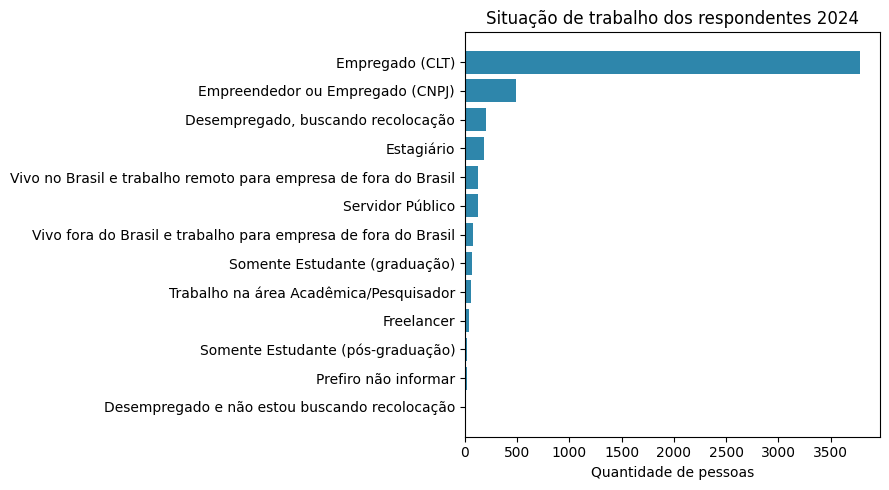

In [7]:
resultado_p1_1 = spark.sql("""
    SELECT
        situacao_trabalho,
        COUNT(*) AS total,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS percentual
    FROM state_of_data_2024
    GROUP BY situacao_trabalho
    ORDER BY total DESC
""")

resultado_p1_1.show(truncate=False)

pdf_p1_1 = resultado_p1_1.toPandas()
grafico_barh(pdf_p1_1 , 'situacao_trabalho', 'total',
             'Situação de trabalho dos respondentes 2024', 'Quantidade de pessoas')



**2. Em quais setores da economia esses profissionais mais atuam? (top 10)**

+------------------------------+-----+
|setor_empresa                 |total|
+------------------------------+-----+
|Finanças ou Bancos            |1035 |
|Tecnologia/Fábrica de Software|941  |
|Varejo                        |380  |
|Área de Consultoria           |353  |
|Outra Opção                   |332  |
|Indústria                     |328  |
|Área da Saúde                 |195  |
|Educação                      |194  |
|Internet/Ecommerce            |153  |
|Setor Alimentício             |143  |
+------------------------------+-----+



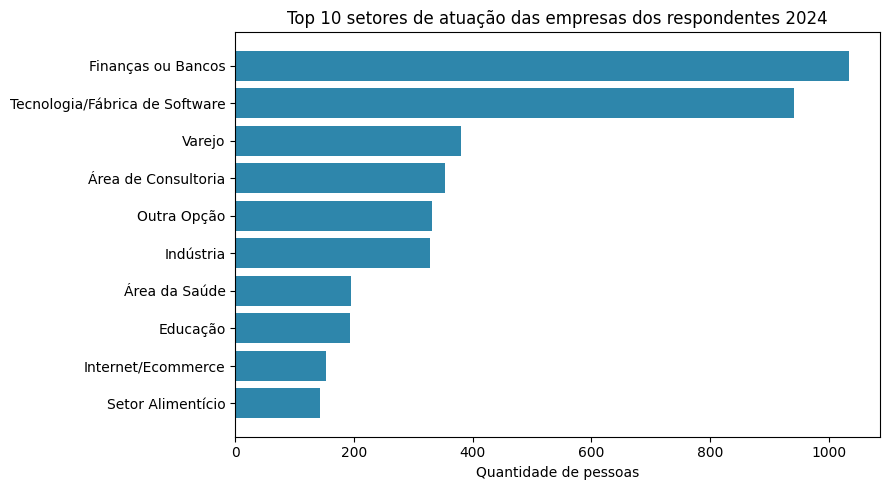

In [8]:
resultado_p1_2 = spark.sql("""
    SELECT setor_empresa, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
    GROUP BY setor_empresa
    ORDER BY total DESC
    LIMIT 10
""")
resultado_p1_2.show(truncate=False)

pdf_p1_2 = resultado_p1_2.toPandas()
grafico_barh(pdf_p1_2 , 'setor_empresa', 'total',
                'Top 10 setores de atuação das empresas dos respondentes 2024', 'Quantidade de pessoas')

**3. Qual a distribuição de cargos atuais na área de dados?**

+-----------------------------------------------------------+-----+
|cargo_atual                                                |total|
+-----------------------------------------------------------+-----+
|Analista de Dados/Data Analyst                             |957  |
|Cientista de Dados/Data Scientist                          |687  |
|Engenheiro de Dados/Data Engineer/Data Architect           |612  |
|Analista de BI/BI Analyst                                  |396  |
|Outra Opção                                                |254  |
|Analytics Engineer                                         |228  |
|Analista de Negócios/Business Analyst                      |184  |
|Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas|122  |
|Engenheiro de Machine Learning/ML Engineer/AI Engineer     |103  |
|Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)  |80   |
|Analista de Suporte/Analista Técnico                       |78   |
|Arquiteto de Dados/Data Architect              

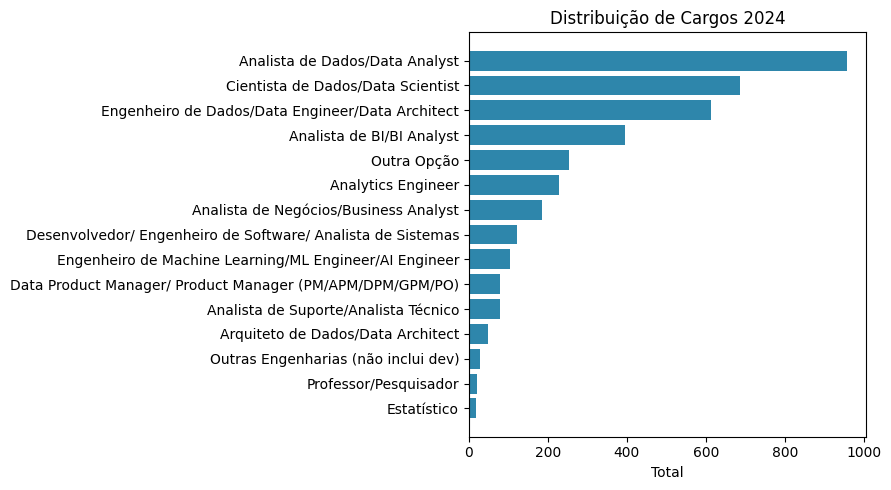

In [9]:
resultado_p1_3 = spark.sql("""
    SELECT cargo_atual, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_tecnica = true
    GROUP BY cargo_atual
    ORDER BY total DESC
""")
resultado_p1_3.show(truncate=False)

pdf_p1_3 = resultado_p1_3.toPandas()
grafico_barh(pdf_p1_3 , 'cargo_atual', 'total', 'Distribuição de Cargos 2024', 'Total')

**4. Qual a distribuição de senioridade no mercado?**

+-----------------+-----+----------+
|nivel_senioridade|total|percentual|
+-----------------+-----+----------+
|Sênior           |1572 |41        |
|Pleno            |1376 |36        |
|Júnior           |868  |23        |
+-----------------+-----+----------+



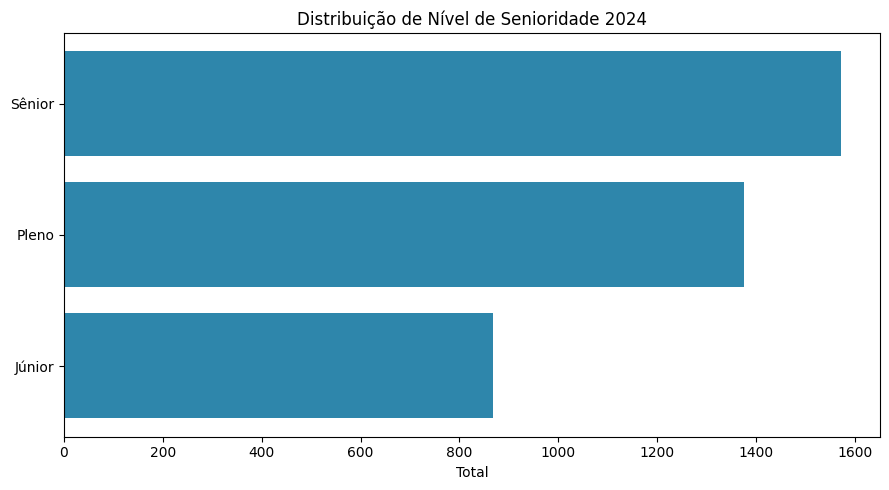

In [10]:
resultado_p1_4 = spark.sql("""
    SELECT
        nivel_senioridade,
        COUNT(*) AS total,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 0) AS percentual
    FROM state_of_data_2024
    WHERE aplica_analise_tecnica = true
    GROUP BY nivel_senioridade
    ORDER BY total DESC
""")
resultado_p1_4.show(truncate=False)

pdf_p1_4 = resultado_p1_4.toPandas()
grafico_barh(pdf_p1_4 , 'nivel_senioridade', 'total', 'Distribuição de Nível de Senioridade 2024', 'Total')

**5. Qual % dos profissionais atua como gestor?**

+------------+
|pct_gestores|
+------------+
|20          |
+------------+



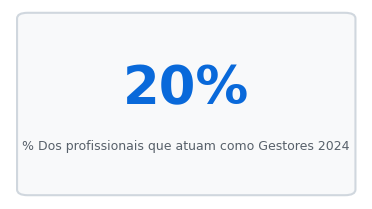

In [11]:
resultado_p1_5 = spark.sql("""
    SELECT
        ROUND(100.0 * SUM(CASE WHEN aplica_analise_gestor THEN 1 ELSE 0 END) / COUNT(*), 0) AS pct_gestores
    FROM state_of_data_2024
""")
resultado_p1_5.show(truncate=False)

# Extrai o valor retornado pela query PySpark
pct_val = resultado_p1_5.collect()[0]['pct_gestores']
valor_formatado = f"{int(pct_val)}%"

# Cria a figura do Card
fig, ax = plt.subplots(figsize=(4, 2.2))
ax.axis('off')

# Desenha o fundo do card
card = patches.FancyBboxPatch(
    (0.05, 0.05), 0.9, 0.9,
    boxstyle="round,pad=0.03",
    facecolor="#F8F9FA",
    edgecolor="#D0D7DE",
    linewidth=1.5
)
ax.add_patch(card)

# Adiciona o valor retornado da query
ax.text(0.5, 0.58, valor_formatado, fontsize=38, fontweight='bold', ha='center', va='center', color='#0969DA')

# Adiciona a legenda
ax.text(0.5, 0.28, '% Dos profissionais que atuam como Gestores 2024', fontsize=9, ha='center', va='center', color='#57606A')

plt.tight_layout()
plt.show()

**6. Qual é a relação entre tempo de experiência em dados e nível de senioridade?**

In [12]:
resultado_p1_6 = spark.sql("""
    SELECT tempo_experiencia_dados, nivel_senioridade, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
    GROUP BY tempo_experiencia_dados, nivel_senioridade
    ORDER BY tempo_experiencia_dados, total DESC
""")
resultado_p1_6.show(50, truncate=False)

+--------------------------------------+-----------------+-----+
|tempo_experiencia_dados               |nivel_senioridade|total|
+--------------------------------------+-----------------+-----+
|Mais de 10 anos                       |Sênior           |245  |
|Mais de 10 anos                       |Pleno            |23   |
|Mais de 10 anos                       |Júnior           |2    |
|Menos de 1 ano                        |Júnior           |240  |
|Menos de 1 ano                        |Pleno            |52   |
|Menos de 1 ano                        |Sênior           |26   |
|Não tenho experiência na área de dados|Júnior           |108  |
|Não tenho experiência na área de dados|Pleno            |47   |
|Não tenho experiência na área de dados|Sênior           |33   |
|de 1 a 2 anos                         |Júnior           |391  |
|de 1 a 2 anos                         |Pleno            |380  |
|de 1 a 2 anos                         |Sênior           |95   |
|de 3 a 4 anos           

**7. Qual modelo de trabalho predomina (remoto, híbrido, presencial) e qual é o desejado?**

+--------------------------------------------------------------------------------------------------------------+-----+
|modelo_trabalho_atual                                                                                         |total|
+--------------------------------------------------------------------------------------------------------------+-----+
|Modelo 100% remoto                                                                                            |2221 |
|Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|998  |
|Modelo híbrido com dias fixos de trabalho presencial                                                          |850  |
|Modelo 100% presencial                                                                                        |792  |
+--------------------------------------------------------------------------------------------------------------+-----+



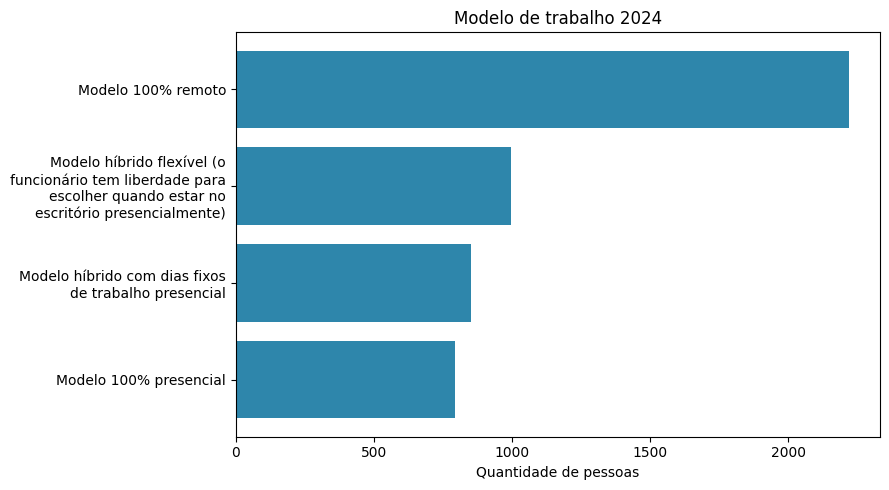

In [13]:
import textwrap

resultado_p1_7 = spark.sql("""
    SELECT modelo_trabalho_atual, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
    GROUP BY modelo_trabalho_atual
    ORDER BY total DESC
""")

resultado_p1_7.show(truncate=False)

pdf_p1_7 = resultado_p1_7.toPandas()

# Aplica a quebra de linha para textos longos (ex: máx. 30 caracteres por linha)
pdf_p1_7['modelo_trabalho_formatado'] = pdf_p1_7['modelo_trabalho_atual'].apply(
    lambda x: textwrap.fill(str(x), width=30)
)

grafico_barh(pdf_p1_7, 'modelo_trabalho_formatado', 'total',
             'Modelo de trabalho 2024', 'Quantidade de pessoas')

+--------------------------------------------------------------------------------------------------------------+-----+
|modelo_trabalho_ideal                                                                                         |total|
+--------------------------------------------------------------------------------------------------------------+-----+
|Modelo 100% remoto                                                                                            |2237 |
|Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|2102 |
|Modelo híbrido com dias fixos de trabalho presencial                                                          |431  |
|Modelo 100% presencial                                                                                        |91   |
+--------------------------------------------------------------------------------------------------------------+-----+



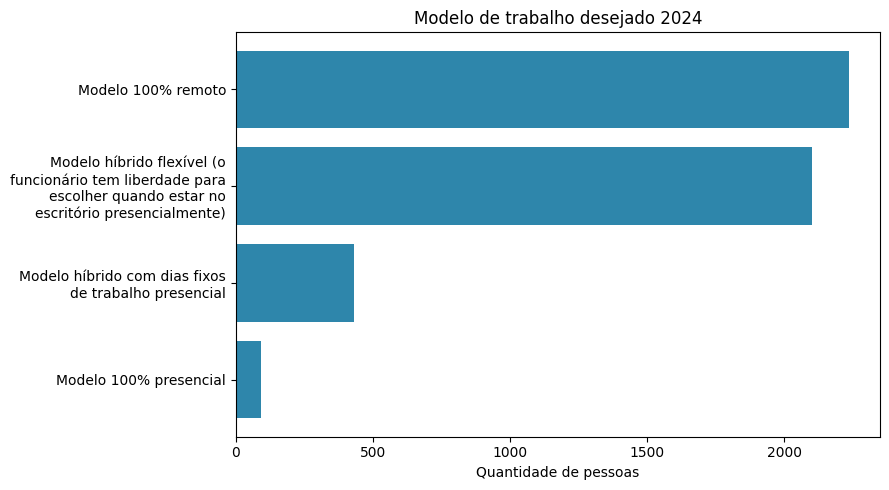

In [14]:
import textwrap


resultado_p1_7_1 = spark.sql("""
    SELECT modelo_trabalho_ideal, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
    GROUP BY modelo_trabalho_ideal
    ORDER BY total DESC
""")

resultado_p1_7_1.show(truncate=False)

pdf_p1_7_1 = resultado_p1_7_1.toPandas()

# Aplica a quebra de linha para textos longos
pdf_p1_7_1['modelo_trabalho_ideal_formatado'] = pdf_p1_7_1['modelo_trabalho_ideal'].apply(
    lambda x: textwrap.fill(str(x), width=30)
)

grafico_barh(pdf_p1_7_1, 'modelo_trabalho_ideal_formatado', 'total',
             'Modelo de trabalho desejado 2024', 'Quantidade de pessoas')

**8. Como se distribui o porte das empresas que possuem times de dados?**

+----------------+-----+
|num_funcionarios|total|
+----------------+-----+
|Acima de 3.000  |2335 |
|de 101 a 500    |760  |
|de 1.001 a 3.000|547  |
|de 501 a 1.000  |444  |
|de 51 a 100     |309  |
|de 11 a 50      |283  |
|de 1 a 5        |113  |
|de 6 a 10       |70   |
+----------------+-----+



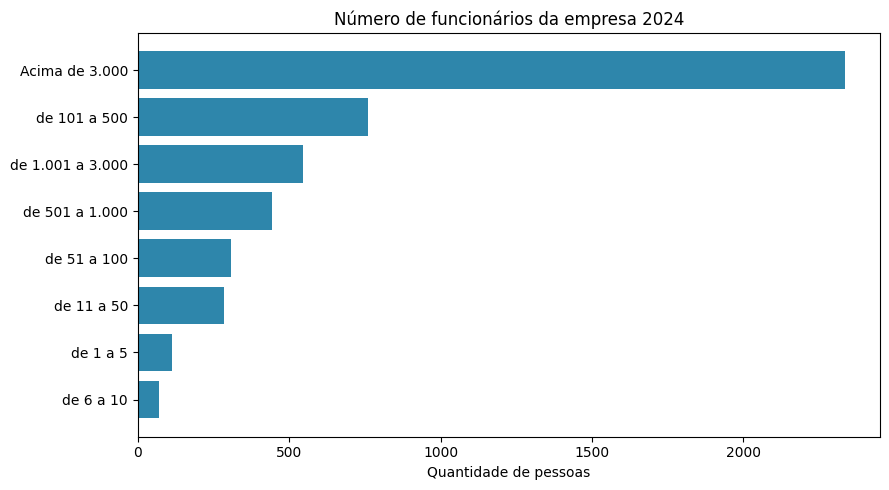

In [15]:
resultado_p1_8 = spark.sql("""
    SELECT num_funcionarios, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
      AND num_funcionarios IS NOT NULL
    GROUP BY num_funcionarios
    ORDER BY total DESC
""")

resultado_p1_8.show(20, truncate=False)

pdf_p1_1_8 = resultado_p1_8.toPandas()
grafico_barh(pdf_p1_1_8, 'num_funcionarios', 'total',
             'Número de funcionários da empresa 2024', 'Quantidade de pessoas')

## P2 — Quais perfis profissionais são mais valorizados pelo mercado?

**1. Qual a faixa salarial por cargo e nivel de senioridade?**

In [16]:
resultado_p2_1 = spark.sql("""
    SELECT cargo_atual, nivel_senioridade, faixa_salarial, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
    GROUP BY cargo_atual, nivel_senioridade, faixa_salarial
    ORDER BY cargo_atual, nivel_senioridade, total DESC
""")
resultado_p2_1.show(100, truncate=False)

+-------------------------------------+-----------------+--------------------------------+-----+
|cargo_atual                          |nivel_senioridade|faixa_salarial                  |total|
+-------------------------------------+-----------------+--------------------------------+-----+
|Analista de BI/BI Analyst            |Júnior           |de R$ 3.001/mês a R$ 4.000/mês  |28   |
|Analista de BI/BI Analyst            |Júnior           |de R$ 2.001/mês a R$ 3.000/mês  |28   |
|Analista de BI/BI Analyst            |Júnior           |de R$ 4.001/mês a R$ 6.000/mês  |27   |
|Analista de BI/BI Analyst            |Júnior           |de R$ 1.001/mês a R$ 2.000/mês  |24   |
|Analista de BI/BI Analyst            |Júnior           |de R$ 6.001/mês a R$ 8.000/mês  |11   |
|Analista de BI/BI Analyst            |Júnior           |Menos de R$ 1.000/mês           |6    |
|Analista de BI/BI Analyst            |Júnior           |de R$ 8.001/mês a R$ 12.000/mês |2    |
|Analista de BI/BI Analyst    

**2. Profissionais com mais tempo de experiência em TI e Dados são mais bem remunerados?**

+--------------------------------------+----------------------+
|tempo_experiencia_dados               |salario_medio_estimado|
+--------------------------------------+----------------------+
|Não tenho experiência na área de dados|6554.0                |
|Menos de 1 ano                        |5048.0                |
|de 1 a 2 anos                         |6660.0                |
|de 3 a 4 anos                         |10316.0               |
|de 5 a 6 anos                         |15245.0               |
|de 7 a 10 anos                        |17994.0               |
|Mais de 10 anos                       |20939.0               |
+--------------------------------------+----------------------+



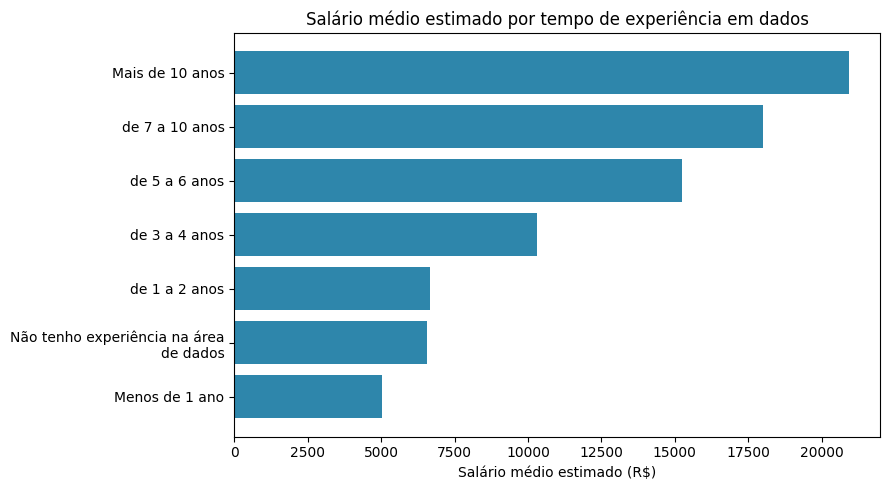

+-------------------------------------------------------------------------------------------------------+----------------------+
|tempo_experiencia_ti                                                                                   |salario_medio_estimado|
+-------------------------------------------------------------------------------------------------------+----------------------+
|Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados|10842.0               |
|Menos de 1 ano                                                                                         |9872.0                |
|de 1 a 2 anos                                                                                          |11491.0               |
|de 3 a 4 anos                                                                                          |12402.0               |
|de 5 a 6 anos                                                                                   

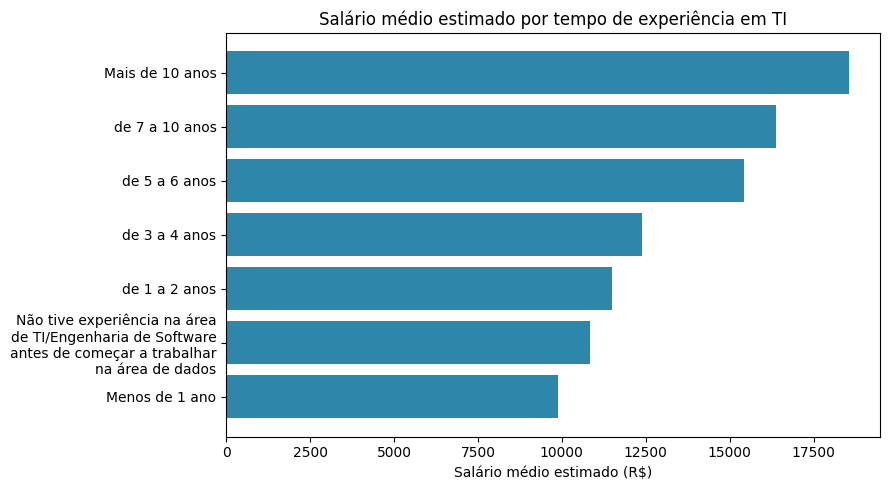

In [17]:
import textwrap

# 1. Análise por Tempo de Experiência em Dados
resultado_p2_2 = spark.sql("""
    SELECT 
        tempo_experiencia_dados, 
        ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true
    GROUP BY tempo_experiencia_dados
    ORDER BY CASE tempo_experiencia_dados
        WHEN 'Não tenho experiência na área de dados' THEN 0
        WHEN 'Menos de 1 ano' THEN 1
        WHEN 'de 1 a 2 anos' THEN 2
        WHEN 'de 3 a 4 anos' THEN 3
        WHEN 'de 4 a 6 anos' THEN 4
        WHEN 'de 5 a 6 anos' THEN 5
        WHEN 'de 7 a 10 anos' THEN 6
        WHEN 'Mais de 10 anos' THEN 7
        ELSE 8
    END ASC
""")
resultado_p2_2.show(truncate=False)

pdf_p2_2 = resultado_p2_2.toPandas()

# Aplica a quebra de linha nos textos da experiência em Dados
pdf_p2_2['tempo_experiencia_dados_formatado'] = pdf_p2_2['tempo_experiencia_dados'].apply(
    lambda x: textwrap.fill(str(x), width=30)
)

grafico_barh(pdf_p2_2, 'tempo_experiencia_dados_formatado', 'salario_medio_estimado',
             'Salário médio estimado por tempo de experiência em dados', 'Salário médio estimado (R$)')


# 2. Análise por Tempo de Experiência em TI
resultado_p2_2_1 = spark.sql("""
    SELECT 
        tempo_experiencia_ti, 
        ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true
    GROUP BY tempo_experiencia_ti
    ORDER BY CASE tempo_experiencia_ti
        WHEN 'Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados' THEN 0
        WHEN 'Menos de 1 ano' THEN 1
        WHEN 'de 1 a 2 anos' THEN 2
        WHEN 'de 3 a 4 anos' THEN 3
        WHEN 'de 4 a 6 anos' THEN 4
        WHEN 'de 5 a 6 anos' THEN 5
        WHEN 'de 7 a 10 anos' THEN 6
        WHEN 'Mais de 10 anos' THEN 7
        ELSE 8
    END ASC
""")
resultado_p2_2_1.show(truncate=False)

pdf_p2_2_1 = resultado_p2_2_1.toPandas()

# Aplica a quebra de linha nos textos longos da experiência em TI
pdf_p2_2_1['tempo_experiencia_ti_formatado'] = pdf_p2_2_1['tempo_experiencia_ti'].apply(
    lambda x: textwrap.fill(str(x), width=30)
)

grafico_barh(pdf_p2_2_1, 'tempo_experiencia_ti_formatado', 'salario_medio_estimado',
             'Salário médio estimado por tempo de experiência em TI', 'Salário médio estimado (R$)')

**3. Existe diferença significativa de remuneração entre profissionais que migraram de TI para dados e os que iniciaram diretamente em dados?**

+-----------------------+----------------------+-----+
|origem                 |salario_medio_estimado|total|
+-----------------------+----------------------+-----+
|Começou direto em dados|10842.0               |2633 |
|Migrou de TI           |13426.0               |2228 |
+-----------------------+----------------------+-----+



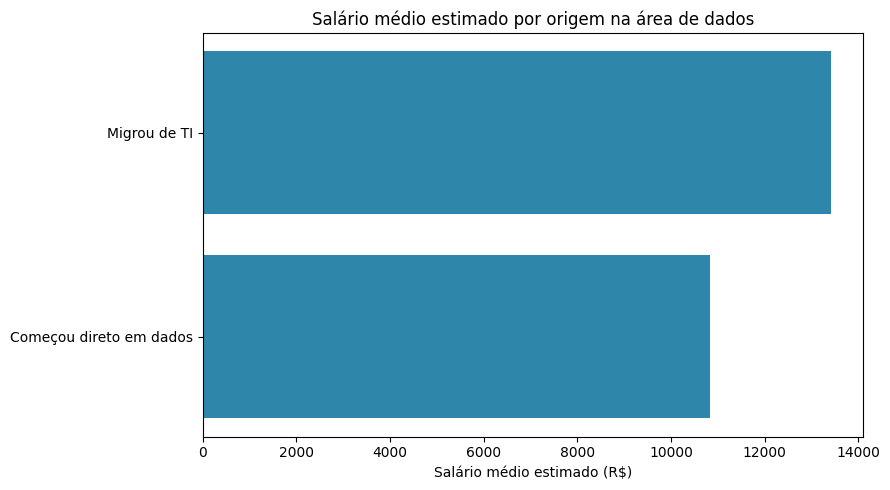

In [18]:
resultado_p2_3 = spark.sql("""
    SELECT
        CASE
            WHEN tempo_experiencia_ti =
                'Não tive experiência na área de TI/Engenharia de Software antes de começar a trabalhar na área de dados'
                THEN 'Começou direto em dados'
            ELSE 'Migrou de TI'
        END AS origem,
        ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado,
        COUNT(*) AS total
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true
      AND tempo_experiencia_ti IS NOT NULL
    GROUP BY 1
    ORDER BY total DESC
""")

resultado_p2_3.show(truncate=False)

pdf_p2_3 = resultado_p2_3.toPandas()
grafico_barh(pdf_p2_3, 'origem', 'salario_medio_estimado',
             'Salário médio estimado por origem na área de dados', 'Salário médio estimado (R$)')

**4. Qual é a relação entre senioridade e remuneração por função (Data Engineer, Data Analytics, Data Science)?**

+---------------------------------+-----------------+----------------------+
|cargo_atual                      |nivel_senioridade|salario_medio_estimado|
+---------------------------------+-----------------+----------------------+
|Analista de Dados/Data Analyst   |Pleno            |7159.0                |
|Cientista de Dados/Data Scientist|Pleno            |9291.0                |
|Cientista de Dados/Data Scientist|Sênior           |15950.0               |
|Analista de Dados/Data Analyst   |Júnior           |4056.0                |
|Analista de Dados/Data Analyst   |Sênior           |12034.0               |
|Cientista de Dados/Data Scientist|Júnior           |5150.0                |
+---------------------------------+-----------------+----------------------+



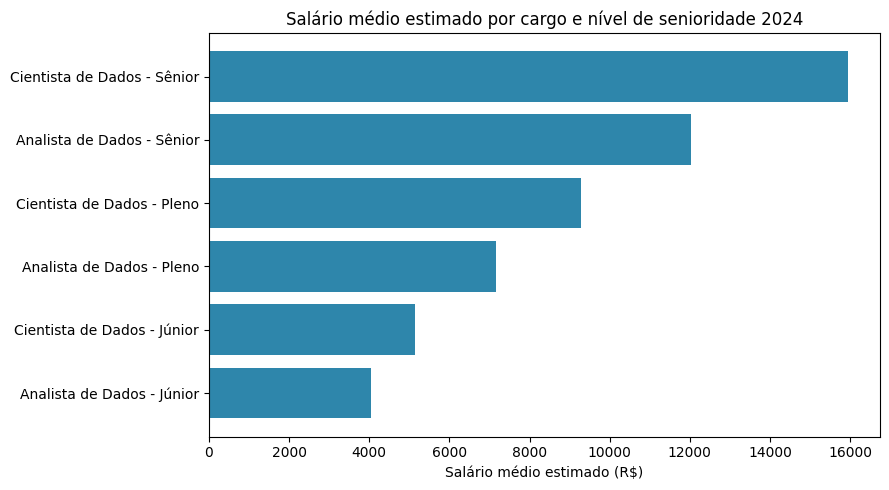

In [19]:
import textwrap
import pandas as pd

# 1. Executa a consulta no PySpark
resultado_p2_4 = spark.sql("""
    SELECT cargo_atual, nivel_senioridade, ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
      AND cargo_atual IN (
          'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect',
          'Analista de Dados/Data Analyst',
          'Cientista de Dados/Data Scientist'
      )
    GROUP BY cargo_atual, nivel_senioridade
""")
resultado_p2_4.show(truncate=False)
pdf_p1_1_4 = resultado_p2_4.toPandas()

# 2. Simplifica o nome dos cargos para o gráfico não ficar poluído
mapeamento_cargos = {
    'Analista de Dados/Data Analyst': 'Analista de Dados',
    'Cientista de Dados/Data Scientist': 'Cientista de Dados',
    'Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados'
}
pdf_p1_1_4['cargo_curto'] = pdf_p1_1_4['cargo_atual'].map(mapeamento_cargos)

# 3. Garante a ordem lógica da senioridade (Júnior -> Pleno -> Sênior)
ordem_senioridade = ['Júnior', 'Pleno', 'Sênior']
pdf_p1_1_4['nivel_senioridade'] = pd.Categorical(pdf_p1_1_4['nivel_senioridade'], categories=ordem_senioridade, ordered=True)
pdf_p1_1_4 = pdf_p1_1_4.sort_values(['cargo_curto', 'nivel_senioridade'])

# 4. Cria a coluna combinada e aplica a quebra de linha
pdf_p1_1_4['cargo_senioridade'] = pdf_p1_1_4['cargo_curto'] + ' - ' + pdf_p1_1_4['nivel_senioridade'].astype(str)
pdf_p1_1_4['cargo_senioridade_formatado'] = pdf_p1_1_4['cargo_senioridade'].apply(lambda x: textwrap.fill(x, width=30))

# 5. Plota o gráfico com as 9 barras individuais
grafico_barh(pdf_p1_1_4, 'cargo_senioridade_formatado', 'salario_medio_estimado',
             'Salário médio estimado por cargo e nível de senioridade 2024', 'Salário médio estimado (R$)')

**5. Quais são os objetivos de carreira mais citados na área de dados? (top 5)** 

In [20]:
resultado_p2_5 = spark.sql("""
    SELECT objetivo_carreira, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = false and objetivo_carreira IS NOT NULL
    GROUP BY objetivo_carreira
    ORDER BY total DESC
""")
resultado_p2_5.show(truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------+-----+
|objetivo_carreira                                                                                                                            |total|
+---------------------------------------------------------------------------------------------------------------------------------------------+-----+
|Migração de carreira: Trabalho em outra área e busco recolocação na área de dados                                                            |105  |
|Preparação profissional: Estou buscando conhecimentos técnicos para no futuro assumir algum cargo na área de dados                           |101  |
|Primeiro emprego: Estou tentando encontrar a primeira oportunidade na área de dados                                                          |84   |
|Apenas conhecimentos: Busco conhecimentos em dados para utilizar na minha área de atuação (não trab

## P3 — Qual é o cenário de diversidade de gênero nas carreiras de dados?

**1. Qual é a proporção de gênero entre os profissionais de dados?**

+--------------------+-----+----------+
|genero              |total|percentual|
+--------------------+-----+----------+
|Masculino           |3967 |76.1      |
|Feminino            |1225 |23.5      |
|Prefiro não informar|15   |0.3       |
|Outro               |8    |0.2       |
+--------------------+-----+----------+



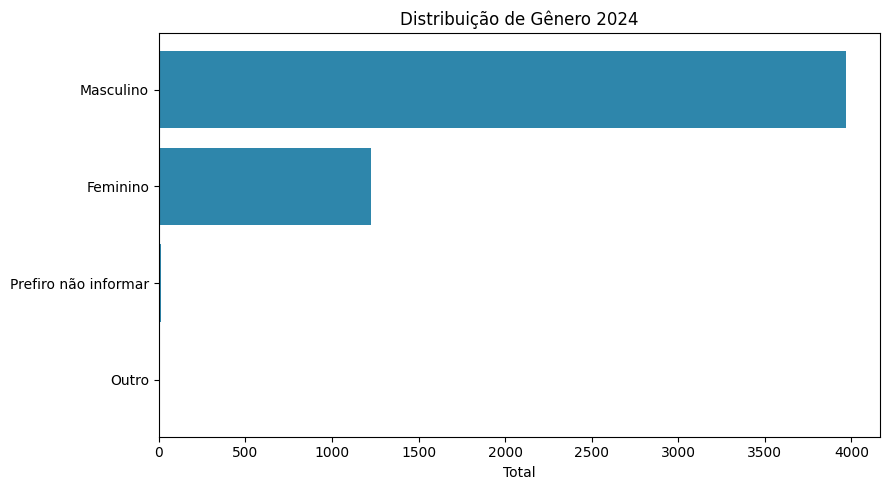

In [21]:
resultado_p3_1 = spark.sql("""
    SELECT genero, COUNT(*) AS total,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS percentual
    FROM state_of_data_2024
    GROUP BY genero
    ORDER BY total DESC
""")
resultado_p3_1.show(truncate=False)

pdf_p1_1_3 = resultado_p3_1.toPandas()
grafico_barh(pdf_p1_1_3, 'genero', 'total', 'Distribuição de Gênero 2024', 'Total')

**2. Existe gap salarial entre gêneros no mesmo cargo e senioridade?**

In [22]:
resultado_p3_2 = spark.sql("""
    SELECT cargo_atual, nivel_senioridade, genero, ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
    GROUP BY cargo_atual, nivel_senioridade, genero
    ORDER BY cargo_atual, nivel_senioridade, genero
""")
resultado_p3_2.show(100, truncate=False)

+-----------------------------------------------------------+-----------------+--------------------+----------------------+
|cargo_atual                                                |nivel_senioridade|genero              |salario_medio_estimado|
+-----------------------------------------------------------+-----------------+--------------------+----------------------+
|Analista de BI/BI Analyst                                  |Júnior           |Feminino            |3250.0                |
|Analista de BI/BI Analyst                                  |Júnior           |Masculino           |3618.0                |
|Analista de BI/BI Analyst                                  |Júnior           |Prefiro não informar|1500.0                |
|Analista de BI/BI Analyst                                  |Pleno            |Feminino            |6765.0                |
|Analista de BI/BI Analyst                                  |Pleno            |Masculino           |6435.0                |
|Analist

**3. Como a representatividade de cor/raça/etnia se distribui entre níveis de senioridade?**

In [23]:
resultado_p3_3 = spark.sql("""
    SELECT nivel_senioridade, cor_raca_etnia, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_tecnica = true
    GROUP BY nivel_senioridade, cor_raca_etnia
    ORDER BY nivel_senioridade, total DESC
""")
resultado_p3_3.show(50, truncate=False)

+-----------------+--------------------+-----+
|nivel_senioridade|cor_raca_etnia      |total|
+-----------------+--------------------+-----+
|Júnior           |Branca              |555  |
|Júnior           |Parda               |208  |
|Júnior           |Preta               |69   |
|Júnior           |Amarela             |26   |
|Júnior           |Prefiro não informar|7    |
|Júnior           |Outra               |2    |
|Júnior           |Indígena            |1    |
|Pleno            |Branca              |896  |
|Pleno            |Parda               |331  |
|Pleno            |Preta               |102  |
|Pleno            |Amarela             |41   |
|Pleno            |Indígena            |3    |
|Pleno            |Prefiro não informar|2    |
|Pleno            |Outra               |1    |
|Sênior           |Branca              |1074 |
|Sênior           |Parda               |344  |
|Sênior           |Preta               |91   |
|Sênior           |Amarela             |48   |
|Sênior      

## P4 — Quais tecnologias apresentam maior adoção entre os profissionais?

**1. Quais linguagens de programação são mais utilizadas no dia a dia?**

+----------+-----+
|linguagem |total|
+----------+-----+
|SQL       |3145 |
|Python    |2934 |
|R         |352  |
|Java      |291  |
|JavaScript|223  |
|VBA       |215  |
|SAS/Stata |130  |
|Scala     |126  |
|C/C++/C#  |46   |
|PHP       |34   |
|.NET      |31   |
|Matlab    |20   |
|Rust      |12   |
|Julia     |6    |
+----------+-----+



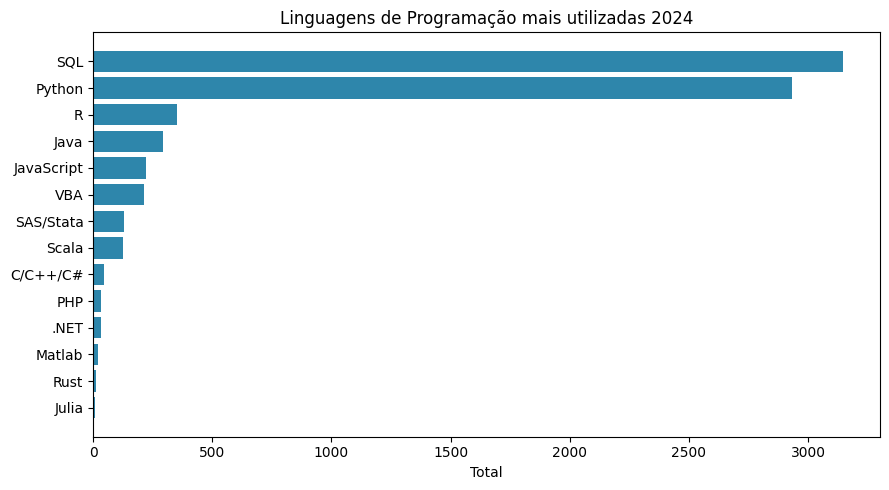

In [24]:
resultado_p4_1 = spark.sql("""
SELECT 'SQL' AS linguagem,
       SUM(CASE WHEN linguagens_trabalho__sql THEN 1 ELSE 0 END) AS total
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'R',
       SUM(CASE WHEN linguagens_trabalho__r THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Python',
       SUM(CASE WHEN linguagens_trabalho__python THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'C/C++/C#',
       SUM(CASE WHEN linguagens_trabalho__c_c_c THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT '.NET',
       SUM(CASE WHEN linguagens_trabalho__net THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Java',
       SUM(CASE WHEN linguagens_trabalho__java THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Julia',
       SUM(CASE WHEN linguagens_trabalho__julia THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'SAS/Stata',
       SUM(CASE WHEN linguagens_trabalho__sas_stata THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'VBA',
       SUM(CASE WHEN linguagens_trabalho__visual_basic_vba THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Scala',
       SUM(CASE WHEN linguagens_trabalho__scala THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Matlab',
       SUM(CASE WHEN linguagens_trabalho__matlab THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Rust',
       SUM(CASE WHEN linguagens_trabalho__rust THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'PHP',
       SUM(CASE WHEN linguagens_trabalho__php THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'JavaScript',
       SUM(CASE WHEN linguagens_trabalho__javascript THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

ORDER BY total DESC
""")

resultado_p4_1.show(20, truncate=False)

pdf_p4_1 = resultado_p4_1.toPandas()
grafico_barh(pdf_p4_1, 'linguagem', 'total', 'Linguagens de Programação mais utilizadas 2024', 'Total')

**2. Qual provedor de cloud predomina e qual é o preferido?**

+------------------+-----+
|cloud             |total|
+------------------+-----+
|AWS               |1583 |
|Azure             |1108 |
|GCP               |1049 |
|On Premise/Nenhuma|463  |
|Oracle Cloud      |143  |
+------------------+-----+



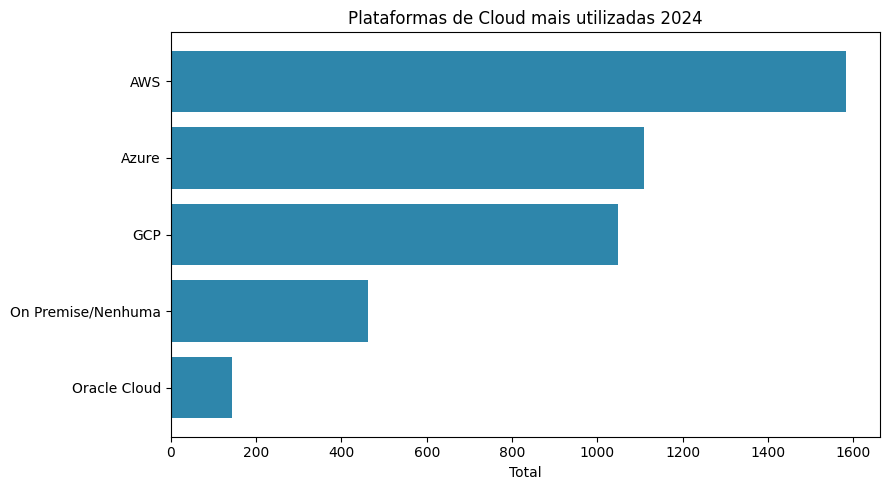

In [25]:
resultado_p4_2 = spark.sql("""
SELECT 'AWS' AS cloud,
       SUM(CASE WHEN cloud__amazon_web_services_aws THEN 1 ELSE 0 END) AS total
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'GCP',
       SUM(CASE WHEN cloud__google_cloud_gcp THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Azure',
       SUM(CASE WHEN cloud__azure_microsoft THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'Oracle Cloud',
       SUM(CASE WHEN cloud__oracle_cloud THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

UNION ALL

SELECT 'On Premise/Nenhuma',
       SUM(CASE WHEN cloud__servidores_on_premise_nao_utilizamos_cloud THEN 1 ELSE 0 END)
FROM state_of_data_2024
WHERE aplica_analise_tecnica = true

ORDER BY total DESC
""")

resultado_p4_2.show(truncate=False)

pdf_p4_2 = resultado_p4_2.toPandas()
grafico_barh(pdf_p4_2, 'cloud', 'total', 'Plataformas de Cloud mais utilizadas 2024', 'Total')

**Lembrete técnico (vale pra qualquer edição):** uso `SUM(CASE WHEN coluna THEN 1 ELSE 0
END)` em vez de `COUNT(coluna)`. Isso não é só estilo - é necessário porque
essas colunas viraram boolean (`true`/`false`), e `COUNT` conta qualquer valor
não-nulo, incluindo os `false`. Se eu usasse `COUNT`, ia contar todo mundo que
respondeu a pergunta de linguagens, não só quem realmente marcou aquela
linguagem específica — o que mudaria o resultado.

## P5 — Qual é o índice de adoção de Inteligência Artificial e seu impacto?

**1. Qual proporção de empresas trata IA Generativa/LLMs como prioridade?**

In [26]:
resultado_p5_1 = spark.sql("""
    SELECT ia_prioridade, COUNT(*) AS total,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS percentual
    FROM state_of_data_2024
    WHERE ia_prioridade IS NOT NULL
    GROUP BY ia_prioridade
    ORDER BY total DESC
""")
resultado_p5_1.show(truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|ia_prioridade                                                                                                                                          |total|percentual|
+-------------------------------------------------------------------------------------------------------------------------------------------------------+-----+----------+
|Sim, está entre nossas principais prioridades para os próximos 2-4 anos (com discussões de iniciativas e orçamentos de curto a médio prazo).           |325  |31.1      |
|Mais ou menos... É uma das várias iniciativas que estamos impulsionando, mas não é uma prioridade (tratam-se de iniciativas isoladas e com pouco foco).|301  |28.8      |
|Sim, é nossa principal prioridade como empresa (com foco executivo significativo e alocação de orçamento relevante).                            

**2. Quem paga pela IA usada no trabalho, o profissional ou a empresa?**

+------------+-----+
|uso_pessoal |total|
+------------+-----+
|Usa grátis  |1943 |
|Usa Copilot |858  |
|Empresa paga|697  |
|Usa e paga  |562  |
|Não usa     |236  |
+------------+-----+



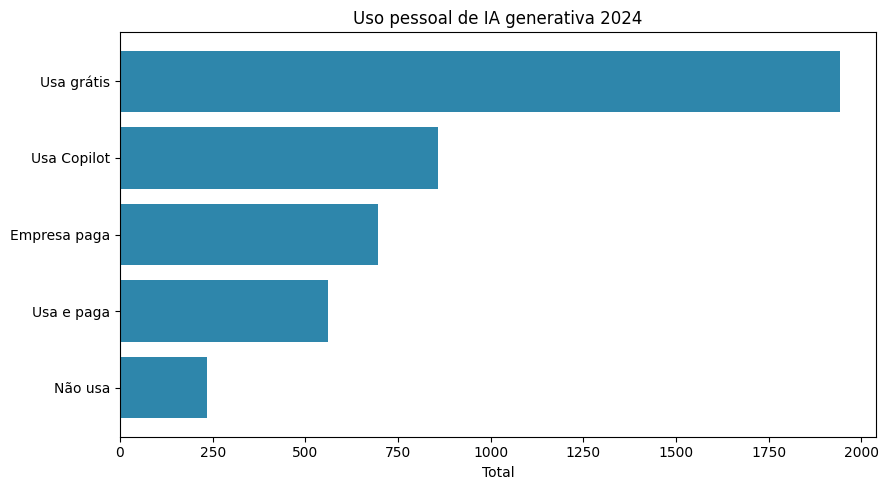

In [27]:
resultado_p5_2 = spark.sql("""
    SELECT 'Não usa' AS uso_pessoal, SUM(CASE WHEN ia_uso_pessoal__nao_uso_solucoes_de_ai_generativa_com_foco_em_produtividade THEN 1 ELSE 0 END) AS total FROM state_of_data_2024
    UNION ALL SELECT 'Usa grátis', SUM(CASE WHEN ia_uso_pessoal__uso_solucoes_gratuitas_de_ai_generativa_com_foco_em_produtividade THEN 1 ELSE 0 END) FROM state_of_data_2024
    UNION ALL SELECT 'Usa e paga', SUM(CASE WHEN ia_uso_pessoal__uso_e_pago_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade THEN 1 ELSE 0 END) FROM state_of_data_2024
    UNION ALL SELECT 'Empresa paga', SUM(CASE WHEN ia_uso_pessoal__a_empresa_que_trabalho_paga_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade THEN 1 ELSE 0 END) FROM state_of_data_2024
    UNION ALL SELECT 'Usa Copilot', SUM(CASE WHEN ia_uso_pessoal__uso_solucoes_do_tipo_copilot THEN 1 ELSE 0 END) FROM state_of_data_2024
    ORDER BY total DESC
""")
resultado_p5_2.show(truncate=False)
grafico_barh(resultado_p5_2.toPandas(), 'uso_pessoal', 'total', 'Uso pessoal de IA generativa 2024', 'Total')

## P6 — Existem diferenças relevantes entre regiões, senioridades ou modelos de trabalho?

**1. Como a faixa salarial varia entre regiões do Brasil?**

**Achado ao revisar o notebook do início ao fim:** essa célula do gráfico usa
`resultado_p6_1`, mas em nenhuma célula anterior essa variável é criada - ela
só tinha output porque rodou em algum momento com uma consulta que não ficou
salva no notebook (provavelmente se perdeu numa reorganização de célula). Se
alguém rodar tudo do zero (`Restart & Run All`), essa célula quebra com
`NameError`. Recriando a consulta que falta, seguindo o mesmo padrão das
outras (`aplica_analise_emprego`, `aplica_analise_tecnica`, `faixa_salarial_num`)
e já juntando região com senioridade - que é exatamente o cuidado de viés de
composição que usamos lá na Silver (P6 e P3): comparar salário só por região,
sem abrir por senioridade, pode confundir "a região paga mais" com "a região
tem mais gente sênior".


In [28]:
resultado_p6_1 = spark.sql("""
    SELECT regiao_atual, nivel_senioridade,
           ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado, COUNT(*) AS total
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
      AND regiao_atual IS NOT NULL
      AND nivel_senioridade IN ('Júnior', 'Pleno', 'Sênior')
    GROUP BY regiao_atual, nivel_senioridade
    ORDER BY regiao_atual, nivel_senioridade
""")
resultado_p6_1.show(30, truncate=False)


+------------+-----------------+----------------------+-----+
|regiao_atual|nivel_senioridade|salario_medio_estimado|total|
+------------+-----------------+----------------------+-----+
|Centro-oeste|Júnior           |4486.0                |71   |
|Centro-oeste|Pleno            |7079.0                |92   |
|Centro-oeste|Sênior           |14529.0               |77   |
|Nordeste    |Júnior           |3627.0                |106  |
|Nordeste    |Pleno            |7340.0                |141  |
|Nordeste    |Sênior           |14748.0               |127  |
|Norte       |Júnior           |3234.0                |16   |
|Norte       |Pleno            |7600.0                |15   |
|Norte       |Sênior           |14711.0               |19   |
|Sudeste     |Júnior           |4106.0                |477  |
|Sudeste     |Pleno            |8109.0                |795  |
|Sudeste     |Sênior           |14614.0               |964  |
|Sul         |Júnior           |3928.0                |183  |
|Sul    

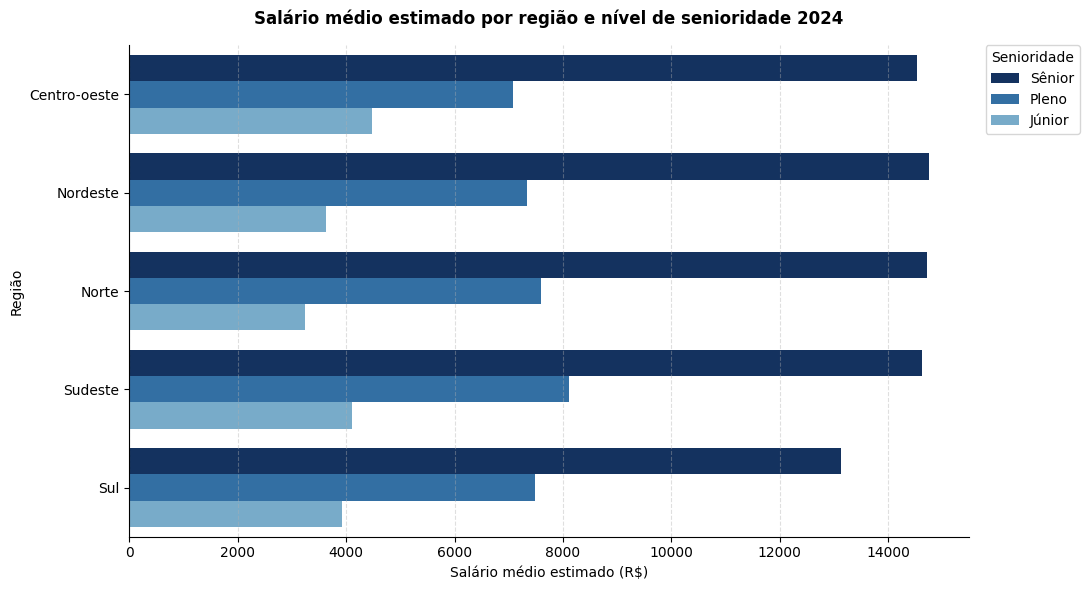

In [29]:
import seaborn as sns

# 1. Prepara os dados
pdf_p1_1_6 = resultado_p6_1.toPandas()

# 2. Define a nova ordem desejada (Sênior primeiro, depois Pleno e Júnior)
ordem_senioridade = ["Sênior", "Pleno", "Júnior"]

# 3. Define as cores associadas a cada nível
paleta_senioridade = {
    "Sênior": "#08306B",  # Azul escuro
    "Pleno": "#2171B5",  # Azul médio
    "Júnior": "#6BAED6",  # Azul claro
}

# 4. Plota o gráfico agrupado
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=pdf_p1_1_6,
    y="regiao_atual",
    x="salario_medio_estimado",
    hue="nivel_senioridade",
    hue_order=ordem_senioridade,  # Define a ordem visual das barras e da legenda
    palette=paleta_senioridade,
)

# 5. Ajustes de títulos e eixos
plt.title(
    "Salário médio estimado por região e nível de senioridade 2024",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Salário médio estimado (R$)")
plt.ylabel("Região")
plt.grid(axis="x", linestyle="--", alpha=0.4)

# 6. Posiciona a legenda fora da área de plotagem (à direita)
plt.legend(
    title="Senioridade", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0
)

sns.despine()
plt.tight_layout()
plt.show()

**2. Existe diferença salarial entre modelos de trabalho (remoto vs presencial vs híbrido)?**

In [30]:
resultado_p6_2 = spark.sql("""
    SELECT nivel_senioridade, modelo_trabalho_atual,
           ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado, COUNT(*) AS total
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true AND aplica_analise_tecnica = true
    GROUP BY nivel_senioridade, modelo_trabalho_atual
    ORDER BY nivel_senioridade, salario_medio_estimado DESC
""")
resultado_p6_2.show(30, truncate=False)

+-----------------+--------------------------------------------------------------------------------------------------------------+----------------------+-----+
|nivel_senioridade|modelo_trabalho_atual                                                                                         |salario_medio_estimado|total|
+-----------------+--------------------------------------------------------------------------------------------------------------+----------------------+-----+
|Júnior           |Modelo híbrido com dias fixos de trabalho presencial                                                          |4584.0                |146  |
|Júnior           |Modelo 100% remoto                                                                                            |4522.0                |301  |
|Júnior           |Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|4344.0                |146  |
|Júnior           |Modelo 100% presencia

**3. Nível de ensino/formação x faixa salarial**

+--------------------------+----------------------+-----+
|nivel_ensino              |salario_medio_estimado|total|
+--------------------------+----------------------+-----+
|Prefiro não informar      |17688.0               |4    |
|Mestrado                  |16358.0               |620  |
|Doutorado ou Phd          |15320.0               |192  |
|Pós-graduação             |13527.0               |1859 |
|Graduação/Bacharelado     |10593.0               |1617 |
|Não tenho graduação formal|9149.0                |77   |
|Estudante de Graduação    |4728.0                |492  |
+--------------------------+----------------------+-----+



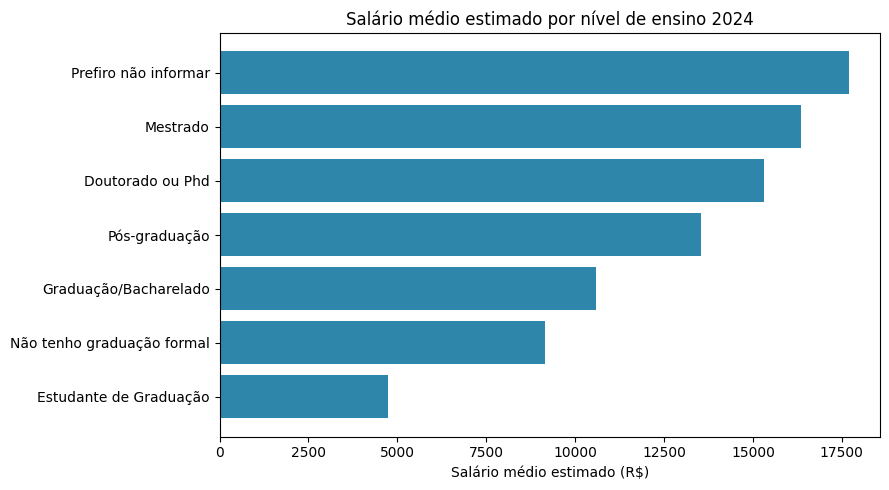

In [31]:
resultado_p6_3 = spark.sql("""
    SELECT nivel_ensino, ROUND(AVG(faixa_salarial_num), 0) AS salario_medio_estimado, COUNT(*) AS total
    FROM state_of_data_2024_num
    WHERE aplica_analise_emprego = true
    GROUP BY nivel_ensino
    ORDER BY salario_medio_estimado DESC
""")
resultado_p6_3.show(truncate=False)

pdf_p6_3 = resultado_p6_3.toPandas()
grafico_barh(pdf_p6_3, 'nivel_ensino', 'salario_medio_estimado',
             'Salário médio estimado por nível de ensino 2024', 'Salário médio estimado (R$)')

**4. Qual seria a atitude dos profissionais diante de um retorno presencial obrigatório?**

+-----------------------------------------------------------+-----+
|atitude_retorno_presencial                                 |total|
+-----------------------------------------------------------+-----+
|Vou procurar outra oportunidade no modelo híbrido ou remoto|2150 |
|Vou procurar outra oportunidade no modelo 100% remoto      |1494 |
|Vou aceitar e retornar ao modelo 100% presencial           |1217 |
+-----------------------------------------------------------+-----+



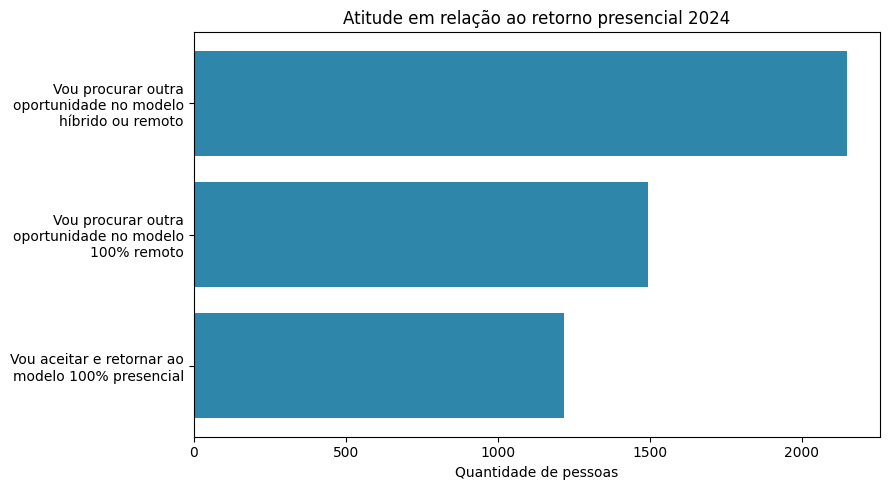

In [32]:
import textwrap

resultado_p6_4 = spark.sql("""
    SELECT atitude_retorno_presencial, COUNT(*) AS total
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
    AND atitude_retorno_presencial IS NOT NULL
    GROUP BY atitude_retorno_presencial
    ORDER BY total DESC
""")

resultado_p6_4.show(truncate=False)

pdf_p6_4 = resultado_p6_4.toPandas()

# Aplica a quebra de linha preservando o \n (limite de 25-30 caracteres)
pdf_p6_4['atitude_retorno_formatada'] = pdf_p6_4['atitude_retorno_presencial'].apply(
    lambda x: textwrap.fill(str(x), width=25)
)

grafico_barh(pdf_p6_4, 'atitude_retorno_formatada', 'total',
             'Atitude em relação ao retorno presencial 2024', 'Quantidade de pessoas')

## P7 — Quais oportunidades e desafios podem ser identificados para empresas que desejam investir em Dados e IA?

**1. Qual é o nível de satisfação geral dos profissionais de dados?**

+------------------+-----+----------+
|satisfeito_empresa|total|percentual|
+------------------+-----+----------+
|Satisfeito        |3334 |68.6      |
|Insatisfeito      |1527 |31.4      |
+------------------+-----+----------+



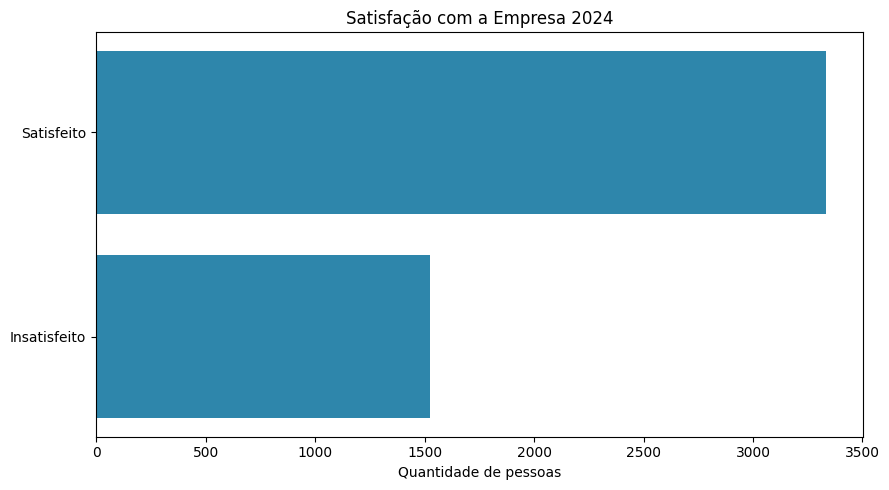

In [33]:
resultado_p7_1 = spark.sql("""
    SELECT
        CASE
            WHEN satisfeito_empresa = true THEN 'Satisfeito'
            WHEN satisfeito_empresa = false THEN 'Insatisfeito'
        END AS satisfeito_empresa,
        COUNT(*) AS total,
        ROUND(
            100.0 * COUNT(*) /
            SUM(COUNT(*)) OVER (),
            1
        ) AS percentual
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
      AND satisfeito_empresa IS NOT NULL
    GROUP BY 1
    ORDER BY total DESC
""")
resultado_p7_1.show(truncate=False)

pdf_p7_1 = resultado_p7_1.toPandas()

grafico_barh(pdf_p7_1, 'satisfeito_empresa', 'total', 
             'Satisfação com a Empresa 2024', 'Quantidade de pessoas')

**2. Qual proporção planeja mudar de emprego nos próximos 6 meses?**

+-----------------------------------------------------------------------+-----+----------+
|pretende_mudar_emprego                                                 |total|percentual|
+-----------------------------------------------------------------------+-----+----------+
|Não estou buscando, mas me considero aberto a outras oportunidades     |1897 |39.0      |
|Não estou buscando e não pretendo mudar de emprego nos próximos 6 meses|1295 |26.6      |
|Estou em busca de oportunidades dentro ou fora do Brasil               |1253 |25.8      |
|Estou em busca de oportunidades, mas apenas fora do Brasil             |416  |8.6       |
+-----------------------------------------------------------------------+-----+----------+



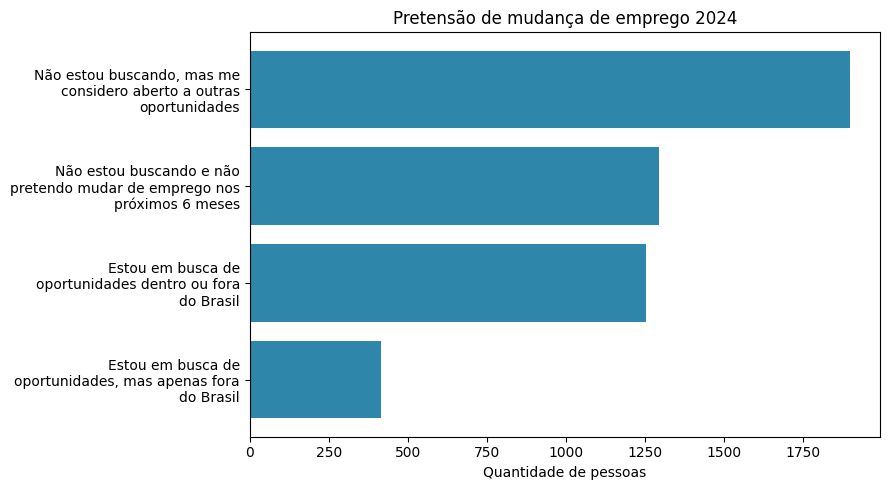

In [34]:
import textwrap


resultado_p7_2 = spark.sql("""
    SELECT pretende_mudar_emprego, COUNT(*) AS total,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS percentual
    FROM state_of_data_2024
    WHERE aplica_analise_emprego = true
    and pretende_mudar_emprego IS NOT NULL
    GROUP BY pretende_mudar_emprego
    ORDER BY total DESC
""")

resultado_p7_2.show(truncate=False)

pdf_p7_2 = resultado_p7_2.toPandas()

pdf_p7_2['pretende_mudar_emprego_formatado'] = pdf_p7_2['pretende_mudar_emprego'].apply(
    lambda x: textwrap.fill(str(x), width=30)
)

grafico_barh(pdf_p7_2, 'pretende_mudar_emprego_formatado', 'total', 
             'Pretensão de mudança de emprego 2024', 'Quantidade de pessoas')

**3. Quais são os desafios mais citados por gestores de dados?**

+----------------------------+-----+
|desafio                     |total|
+----------------------------+-----+
|Dividir tempo técnico/gestão|319  |
+----------------------------+-----+



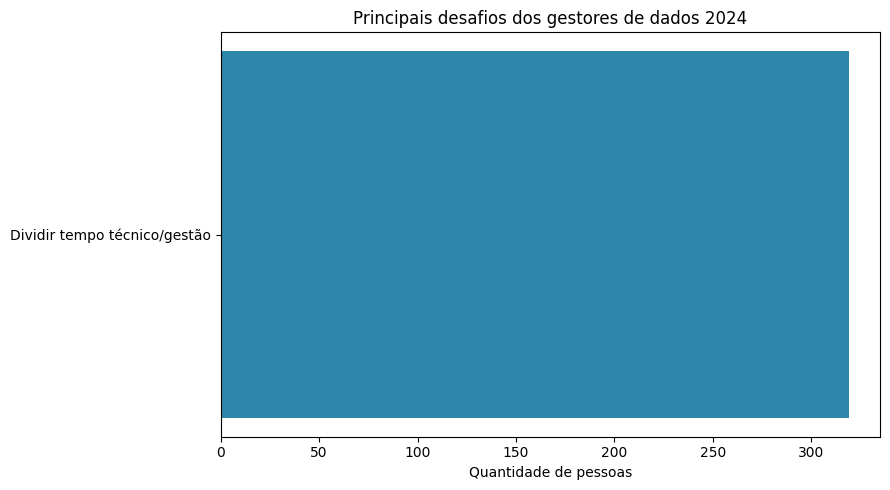

In [35]:
resultado_p7_3 = spark.sql("""
    SELECT desafio, total
    FROM (
        SELECT 
            SUM(CAST(desafios_gestor__a_contratar_novos_talentos AS INT)) AS `Contratar talentos`,
            SUM(CAST(desafios_gestor__b_reter_talentos AS INT)) AS `Reter talentos`,
            SUM(CAST(desafios_gestor__c_convencer_a_empresa_a_aumentar_os_investimentos_na_area_de_dados AS INT)) AS `Convencer a empresa a investir`,
            SUM(CAST(desafios_gestor__d_gestao_de_equipes_no_ambiente_remoto AS INT)) AS `Gestão de equipes remotas`,
            SUM(CAST(desafios_gestor__g_conseguir_processar_e_armazenar_um_alto_volume_de_dados AS INT)) AS `Processar/armazenar alto volume`,
            SUM(CAST(desafios_gestor__h_conseguir_gerar_valor_para_as_areas_de_negocios_atraves_de_estudos_e_experimentos AS INT)) AS `Gerar valor para o negócio`,
            SUM(CAST(desafios_gestor__i_desenvolver_e_manter_modelos_machine_learning_em_producao AS INT)) AS `Modelos de ML em produção`,
            SUM(CAST(desafios_gestor__dividir_o_tempo_entre_entregas_tecnicas_e_gestao AS INT)) AS `Dividir tempo técnico/gestão`
        FROM state_of_data_2024
        WHERE aplica_analise_gestor = true
    )
    UNPIVOT (
        total FOR desafio IN (
            `Contratar talentos`, 
            `Reter talentos`, 
            `Convencer a empresa a investir`, 
            `Gestão de equipes remotas`, 
            `Processar/armazenar alto volume`, 
            `Gerar valor para o negócio`, 
            `Modelos de ML em produção`, 
            `Dividir tempo técnico/gestão`
        )
    )
    ORDER BY total DESC
""")
resultado_p7_3.show(truncate=False)

pdf_p7_3 = resultado_p7_3.toPandas()
grafico_barh(pdf_p7_3, 'desafio', 'total',
             'Principais desafios dos gestores de dados 2024', 'Quantidade de pessoas')  

## 4. Exportando as tabelas Gold

Com todas as perguntas respondidas, chegou a hora de persistir cada resultado
como uma tabela Gold - assim quem for montar a apresentação executiva (ou
plugar isso num QuickSight/Athena) não precisa rodar Spark de novo, só ler o
Parquet pronto.

Decidi exportar **uma tabela por sub-pergunta**, não só uma tabela "geral" por
pergunta principal - cada sub-pergunta tem um agrupamento (`GROUP BY`)
diferente, então forçar tudo numa tabela só ia significar ou perder detalhe ou
misturar grãos diferentes na mesma tabela (o que complica muito a leitura
depois). Em compensação, organizo essas tabelas dentro de **7 pastas**, uma
por pergunta principal do desafio - assim quem for procurar "os dados de
diversidade de gênero" sabe exatamente onde olhar, mesmo tendo várias tabelas
lá dentro.

Os caminhos abaixo são locais pra eu testar - na submissão final do desafio,
troco pelo caminho do bucket S3 do grupo, algo tipo
`s3://<bucket-do-grupo>/gold/p3_diversidade/gap_salarial_genero/`.


In [36]:
from utils.config import CAMINHO_GOLD_BASE

ANO_PESQUISA = 2024 # vinicius e maycon substituam aqui esse número pro ano da base que analisou

tabelas_por_pergunta = {
    "p1_estrutura_mercado": {
        "situacao_trabalho": resultado_p1_1,
        "setor_top10": resultado_p1_2,
        "distribuicao_cargos": resultado_p1_3,
        "distribuicao_senioridade": resultado_p1_4,
        "percentual_gestores": resultado_p1_5,
        "experiencia_x_senioridade": resultado_p1_6,
        "modelo_trabalho_atual": resultado_p1_7,
        "modelo_trabalho_ideal": resultado_p1_7_1,
        "porte_empresa": resultado_p1_8,
    },
    "p2_perfis_valorizados": {
        "salario_por_cargo_senioridade": resultado_p2_1,
        "salario_por_experiencia_dados": resultado_p2_2,
        "salario_por_experiencia_ti": resultado_p2_2_1,
        "salario_migracao_ti": resultado_p2_3,
        "salario_por_funcao_senioridade": resultado_p2_4,
        "objetivos_carreira_top5": resultado_p2_5,
    },
    "p3_diversidade": {
        "proporcao_genero": resultado_p3_1,
        "gap_salarial_genero": resultado_p3_2,
        "raca_por_senioridade": resultado_p3_3,
    },
    "p4_tecnologias": {
        "linguagens_mais_usadas": resultado_p4_1,
        "cloud_predominante": resultado_p4_2,
    },
    "p5_ia_generativa": {
        "prioridade_ia_empresa": resultado_p5_1,
        "quem_paga_ia": resultado_p5_2,
    },
    "p6_diferencas_regionais": {
        "salario_por_regiao_senioridade": resultado_p6_1,
        "salario_por_modelo_trabalho": resultado_p6_2,
        "salario_por_nivel_ensino": resultado_p6_3,
        "atitude_retorno_presencial": resultado_p6_4,
    },
    "p7_oportunidades_desafios": {
        "satisfacao_geral": resultado_p7_1,
        "intencao_troca_emprego": resultado_p7_2,
        "desafios_gestores": resultado_p7_3,
    },
}

# só sobrescreve a partição do próprio ano na hora de gravar - sem isso, "overwrite"
# apaga a pasta inteira (todos os anos), não só a partição que estou escrevendo agora
spark.conf.set(
    "spark.sql.sources.partitionOverwriteMode",
    "dynamic"
)

for pasta, tabelas in tabelas_por_pergunta.items():

    for nome_tabela, df_resultado in tabelas.items():

        caminho = CAMINHO_GOLD_BASE / pasta / nome_tabela

        (
            df_resultado
            .withColumn("ano_pesquisa", F.lit(ANO_PESQUISA))
            .write
            .mode("overwrite")
            .partitionBy("ano_pesquisa")
            .parquet(str(caminho))
        )

    print(
        f"{pasta}: {len(tabelas)} tabela(s) exportada(s)"
    )

total_tabelas = sum(
    len(tabelas)
    for tabelas in tabelas_por_pergunta.values()
)

print(
    f"\nTotal: {total_tabelas} tabelas Gold exportadas."
)

print(
    f"Partição: ano_pesquisa={ANO_PESQUISA}"
)

p1_estrutura_mercado: 9 tabela(s) exportada(s)
p2_perfis_valorizados: 6 tabela(s) exportada(s)
p3_diversidade: 3 tabela(s) exportada(s)
p4_tecnologias: 2 tabela(s) exportada(s)
p5_ia_generativa: 2 tabela(s) exportada(s)
p6_diferencas_regionais: 4 tabela(s) exportada(s)
p7_oportunidades_desafios: 3 tabela(s) exportada(s)

Total: 29 tabelas Gold exportadas.
Partição: ano_pesquisa=2024


## 5. Conclusão

A Gold ficou com 29 tabelas, organizadas nas 7 pastas por pergunta do
desafio, cada uma já no grão certo pra virar gráfico ou card na apresentação
executiva direto, sem precisar processar nada de novo.

**Ponto em aberto pro grupo:** vale discutir se granularidade de "uma tabela por sub-pergunta" (29 no total) é o formato final que queremos entregar, ou se compensa consolidar algumas em tabelas mais largas antes da apresentação — principalmente as que só têm 1-2 colunas de resultado.